In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from numpy import pi, e
from numpy.linalg import inv, det
from numpy.linalg import norm as LA_norm
from numpy.random import random
from scipy.stats import norm
from sklearn.datasets import make_spd_matrix
from termcolor import colored
import itertools
from itertools import combinations, product

In [2]:
def initial_inputs(flag):
    if flag == 0:
        B = np.random.rand(m, n)
        Sigma_W = make_spd_matrix(m)
        return np.concatenate(([flag], B.reshape((m*n)), Sigma_W.reshape((m*m))))
    else:
        A = np.random.rand(n, m)
        Sigma_Z = np.diag(random(n))
        return np.concatenate(([flag], A.reshape((n*m)), Sigma_Z.reshape((n*n))))

def is_close_to_zero(arr, etol):
    return np.allclose(arr, 0, atol=etol)

def is_singular(matrix):
    is_singular = np.linalg.matrix_rank(matrix) < min(matrix.shape)
    if is_singular:
        print(colored('The matrix is singular.', 'red', attrs=['bold']))
    else:
        print(colored('The matrix is not singular.', 'red', attrs=['bold']))

def is_positive_definite(matrix):
    if np.all(np.linalg.eigvals(matrix) > 0):
        print(colored('The matrix is positive definite.', 'red', attrs=['bold']))
    else:
        print(colored('The matrix is not positive definite.', 'red', attrs=['bold']))

def matrix_B(A, Sigma_Z, beta, lamda):
    inv_Sigma_Z_hat = inv(Sigma_Z) + 2 * lamda * np.identity(n)
    B = inv(beta * np.identity(m) + A.T @ inv_Sigma_Z_hat @ A) @ A.T @ inv_Sigma_Z_hat
    return B

def covariance_matrix_W(A, Sigma_Z, beta, lamda):
    inv_Sigma_Z_hat = inv(Sigma_Z) + 2 * lamda * np.identity(n)
    Sigma_W = beta * inv(beta * np.identity(m) + A.T @ inv_Sigma_Z_hat @ A)
    return Sigma_W

def matrix_A(B, Sigma_W):
    A = inv(inv(Sigma_Y) + B.T @ inv(Sigma_W) @ B) @ B.T @ inv(Sigma_W)
    return A

def covariance_matrix_Z(B, Sigma_W):
    Sigma_Z = inv(inv(Sigma_Y) + B.T @ inv(Sigma_W) @ B)
    diagonalized_Sigma_Z = np.diag(Sigma_Z.diagonal())
    return diagonalized_Sigma_Z

def covariance_matrix_XV(B, Sigma_V, Sigma_W):
    cov_XV = np.block([[B @ Sigma_Y @ B.T + Sigma_W, B @ Gamma @ Sigma_V],
                       [(B @ Gamma @ Sigma_V).T, Sigma_V]])
    return cov_XV

def encoder_mi(B, Sigma_W):
    return 0.5 * np.log(det(B @ Sigma_Y @ B.T + Sigma_W) / det(Sigma_W))

def decoder_mi(A, Sigma_Z):
    return 0.5 * np.log(det(A @ A.T + Sigma_Z) / det(Sigma_Z))

def cov_recon_error(recon, orig):
    norm_diff = LA_norm(orig - recon, 2)
    orig_norm = LA_norm(orig, 2)
    recon_err = norm_diff / orig_norm
    return recon_err

In [3]:
def safe_logdet(matrix):
    try:
        d = det(matrix)
        if d <= 0 or np.isnan(d) or np.isinf(d):
            return None
        return np.log(d)
    except:
        return None

def objective_function(A, B, Sigma_Z, Sigma_W, beta, lamda):
    try:
        Sigma_X = B @ Sigma_Y @ B.T + Sigma_W

        log_det_Sigma_W = safe_logdet(Sigma_W)
        log_det_Sigma_Z = safe_logdet(Sigma_Z)

        if log_det_Sigma_W is None or log_det_Sigma_Z is None:
            return 10000

        inv_Sigma_Z = inv(Sigma_Z)

        regularizer = 0.5 * (np.trace(Sigma_X) - log_det_Sigma_W - m)

        reconstruction = -0.5 * (np.trace(A.T @ inv_Sigma_Z @ Sigma_Y @ B.T) + \
                                 np.trace(inv_Sigma_Z @ A @ B @ Sigma_Y) - \
                                 np.trace(inv_Sigma_Z @ Sigma_Y) - \
                                 np.trace(A.T @ inv_Sigma_Z @ A @ Sigma_X) - \
                                 n * np.log(2 * pi) - log_det_Sigma_Z)

        l2_norm_loss = np.trace((np.identity(n) - A @ B) @ Sigma_Y @ (np.identity(n) - A @ B).T + A @ Sigma_W @ A.T)

        return reconstruction + beta * regularizer + lamda * l2_norm_loss

    except Exception as e:
        return 10000

In [4]:
def print_comprehensive_results(beta, lamda, flag, m, n):
    if flag == 0:
        # Generate random initial encoder inputs (B, Sigma_W)
        B, Sigma_W = initial_inputs(flag)[1:1+m*n].reshape((m, n)), initial_inputs(flag)[1+m*n:1+m*n+m*m].reshape((m, m))
    else:
        # Generate random initial decoder inputs (A, Sigma_Z)
        A, Sigma_Z = initial_inputs(flag)[1:1+n*m].reshape((n, m)), initial_inputs(flag)[1+n*m:1+n*m+n*n].reshape((n, n))

    opt_sol = rate_distortion(initial_inputs(flag), beta, lamda)
            
    en_mi = round(opt_sol[2*n*m+n*n+m*m+1:2*n*m+n*n+m*m+2][0], 4)
    de_mi = round(opt_sol[2*n*m+n*n+m*m+2:2*n*m+n*n+m*m+3][0], 4)
    err = opt_sol[-1]
            
    return [en_mi, de_mi, opt_sol, err]

In [5]:
"""

*****************************************************************
**                          ALGORITHM                          **
*****************************************************************
   
Inputs:
- MAX_ITERS: Maximum number of iterations
- n, m: Dimensions of the matrix
- TOL_ERR: Tolerable error
- Sigma_Y: A random nxn positive definite matrix

Algorithm:
1. Initialize flag
    a. If we start with the encoder, set flag = 0.
    b. Otherwise, set flag = 1.
    
2. Generate initial inputs for the iteration step
    a. If flag = 0, then do:
        i. create random initial encoder inputs, including 
            - a random mxn matrix B
            - a random mxm positive definite covariance matrix Sigma_W
        ii. set flag = 1.
    b. If flag = 1, then do:
        i. create random initial decoder inputs, including 
            - a random nxm matrix A
            - a random nxn positive definite covariance matrix Sigma_Z
        ii. set flag = 0.
        
3. Set iteration counter i = 0. 

4. Iterative step
    a. If flag = 0, given the decoder inputs (A, Sigma_Z) at iteration i,
        i. compute the corresponding encoder inputs at iteration i+1:
            B = matrix_B(A, Sigma_Z)
            Sigma_W = covariance_matrix_W(A, Sigma_Z)
        ii. set flag = 1.
        iii. compute the resulting beta-VAE cost function and mutual information of the encoder.
        iv. check for convergence after the second iteration:
            - if converges, conclude that the algorithm converges and skip to step 7.
            - unless, check if the maximum number of iterations has been reached:
                - if it is, conclude that the algorithm failed to converge and skip to step 7.
                - otherwise, move to step 5.
    b. If flag = 1, given the encoder inputs (B, Sigma_W) at iteration i,
        i. compute the corresponding decoder inputs at iteration i:
            A = matrix_A(B, Sigma_W)
            Sigma_Z = covariance_matrix_Z(B, Sigma_W, is_diagonal)
        ii. set flag = 0.
        iii. compute the resulting beta-VAE cost function and mutual information of the decoder.
        iv. check for convergence after the second iteration:
            - if converges, conclude that the algorithm converges and skip to step 7.
            - unless, check if the maximum number of iterations has been reached:
                - if it is, conclude that the algorithm failed to converge and skip to step 7.
                - otherwise, move to step 5.
            
5. Increment iteration counter i <- i + 1.

6. If the iteration counter i < MAX_ITERS, then move back to step 4.
    Otherwise, move to step 7.
    
7. Compute the values of Sigma_X and Sigma_Y_hat.
        
8. Display results
    
9. Stop.

"""

def rate_distortion(inputs, beta, lamda):
    flag = inputs[0]
    if flag == 0:
        B = inputs[1:1+m*n].reshape((m, n))
        Sigma_W = inputs[1+m*n:1+m*n+m*m].reshape((m, m))
        flag = 1
        # Array of current encoder inputs (B_t, Sigma_W_t)
        current_encoder_inputs = np.concatenate((B.reshape((m*n)), Sigma_W.reshape((m*m))))
    else:
        A = inputs[1:1+n*m].reshape((n, m))
        Sigma_Z = inputs[1+n*m:1+n*m+n*n].reshape((n, n))
        flag = 0
        # Array of current decoder inputs (A_t, Sigma_Z_t)
        current_decoder_inputs = np.concatenate((A.reshape((n*m)), Sigma_Z.reshape((n*n))))
    
    # Cost function and mutual information arrays
    cf_arr = []
    en_mi_arr = []
    de_mi_arr = [] 
    err = 0

    # Iteration step
    try:
        for i in range(0, MAX_ITERS):
            if  flag == 0:
                B = matrix_B(A, Sigma_Z, beta, lamda)
                Sigma_W = covariance_matrix_W(A, Sigma_Z, beta, lamda)
                flag = 1
                
                current_obj = round(objective_function(A, B, Sigma_Z, Sigma_W, beta, lamda), 4)     
                if current_obj == 10000:
                    err = 1
                    break
                    
                cf_arr = np.concatenate((cf_arr, [current_obj]))
                current_en_mi = encoder_mi(B, Sigma_W)
                en_mi_arr = np.concatenate((en_mi_arr, [current_en_mi]))
                
                # For the first iteration, update the current encoder inputs
                if i == 0:
                    current_encoder_inputs = np.concatenate((B.reshape((m*n)), Sigma_W.reshape((m*m))))
                # From the second iteration, compute the Frobenius norm of the difference between
                #    i. B and itself in the previous iteration
                #    ii. Sigma_W and itself in the previous iteration
                else:
                    B_diff = B - current_encoder_inputs[:m*n].reshape((m, n))
                    B_norm_diff = LA_norm(B_diff, 'fro')
                    Sigma_W_diff = Sigma_W - current_encoder_inputs[m*n:m*n+m*m].reshape((m, m))
                    Sigma_W_norm_diff = LA_norm(Sigma_W_diff, 'fro')

                    current_encoder_inputs = np.concatenate((B.reshape((m*n)), Sigma_W.reshape((m*m))))
                    # Check for convergence
                    if B_norm_diff <= TOL_ERR and Sigma_W_norm_diff <= TOL_ERR:
                        print(colored('\nThe algorithm converges after {} iterations.'.format(i+1), 'blue', attrs=['bold']))
                        print('The objective function value is {}.'.format(current_obj))
                        break
            else:
                A = matrix_A(B, Sigma_W)
                Sigma_Z = covariance_matrix_Z(B, Sigma_W)
                flag = 0
                
                current_obj = round(objective_function(A, B, Sigma_Z, Sigma_W, beta, lamda), 4)
                if current_obj == 10000:
                    err = 1
                    break
                                    
                cf_arr = np.concatenate((cf_arr, [current_obj]))
                current_de_mi = decoder_mi(A, Sigma_Z)
                de_mi_arr = np.concatenate((de_mi_arr, [current_de_mi]))
                
                Sigma_Y_hat = A @ A.T + Sigma_Z
                recon_err = cov_recon_error(Sigma_Y_hat, Sigma_Y)
                
                # For the first iteration, update the current decoder inputs
                if i == 0:
                    current_decoder_inputs = np.concatenate((A.reshape((n*m)), Sigma_Z.reshape((n*n))))

                # From the second iteration, compute the Frobenius norm of the difference between
                #    i. A and itself in the previous iteration
                #    ii. Sigma_Z and itself in the previous iteration                
                else:
                    A_diff = A - current_decoder_inputs[:n*m].reshape((n, m))
                    A_norm_diff = LA_norm(A_diff, 'fro')
                    Sigma_Z_diff = Sigma_Z - current_decoder_inputs[n*m:n*m+n*n].reshape((n, n))
                    Sigma_Z_norm_diff = LA_norm(Sigma_Z_diff, 'fro')

                    current_decoder_inputs = np.concatenate((A.reshape((n*m)), Sigma_Z.reshape((n*n))))
                    # Check for convergence
                    if A_norm_diff <= TOL_ERR and Sigma_Z_norm_diff <= TOL_ERR:
                        print(colored('\nThe algorithm converges after {} iterations.'.format(i+1), 'blue', attrs=['bold']))
                        print('The objective function value is {}.'.format(current_obj))
                        break                       

        # Compute Sigma_X and Sigma_Y_hat  
        Sigma_X = B @ Sigma_Y @ B.T + Sigma_W
        Sigma_Y_hat = A @ A.T + Sigma_Z

        if i == MAX_ITERS-1:
            err = 1
        
        sol = np.concatenate((A.reshape((n*m)), B.reshape((m*n)),
                              Sigma_Z.reshape((n*n)), Sigma_W.reshape((m*m)),
                              [current_obj], [current_en_mi], [current_de_mi],
                              [len(cf_arr)], [len(en_mi_arr)], [len(de_mi_arr)],
                              Sigma_X.reshape((m*m)), Sigma_Y_hat.reshape((n*n)),
                              cf_arr, en_mi_arr, de_mi_arr, [recon_err], [err]))
        return sol
    
    except Exception as e:
         
        Sigma_X = B @ Sigma_Y @ B.T + Sigma_W
        Sigma_Y_hat = A @ A.T + Sigma_Z

        if i == MAX_ITERS-1:
            err = 1
            
        sol = np.concatenate((A.reshape((n*m)), B.reshape((m*n)),
                              Sigma_Z.reshape((n*n)), Sigma_W.reshape((m*m)),
                              [current_obj], [current_en_mi], [current_de_mi], 
                              [len(cf_arr)], [len(en_mi_arr)], [len(de_mi_arr)],
                              Sigma_X.reshape((m*m)), Sigma_Y_hat.reshape((n*n)),
                              cf_arr, en_mi_arr, de_mi_arr, [recon_err], [err]))
        return sol

## I. Inputs

In [6]:
def generate_Sigma_V(case):
    for case_idx in range(num_cases):
        if case_idx == 0:
            # Case 1: Independent of generative variables
            std_devs = [std_dev_v1, std_dev_v2, std_dev_v3]
            V_1 = [np.random.normal(mean, std_dev, size=num_samples) for std_dev in std_devs]
            Sigma_V_1 = np.round(np.cov(V_1), 4)
        
        elif case_idx == 1:
            # Case 2: Linear dependence of v_1 and v_2, with independence of v_3
            v_1 = np.random.normal(mean, std_dev_v1, size=num_samples)
            v_3 = np.random.normal(mean, std_dev_v3, size=num_samples)
            random_noise_z2 = np.random.normal(mean, std_dev_z2, num_samples)
            v_2 = alpha * v_1 + random_noise_z2
            V_2 = np.array([v_1, v_2, v_3])
            Sigma_V_2 = np.round(np.cov(V_2), 4)  
        
        else:
            # Case 3: Linear dependence of v_2 and v_3, with v_1
            v_1 = np.random.normal(mean, std_dev_v1, size=num_samples)
            random_noise_z2 = np.random.normal(mean, std_dev_z2, num_samples)
            random_noise_z3 = np.random.normal(mean, std_dev_z3, num_samples)
            v_2 = alpha * v_1 + random_noise_z2
            v_3 = beta_reg * v_1 + random_noise_z3
            V_3 = np.array([v_1, v_2, v_3])
            Sigma_V_3 = np.round(np.cov(V_3), 4)
    
    if case == 0:
        print(colored('Scenario 1:', attrs=['bold','underline']))
        print(f'Given (sigma_v1, sigma_v2, sigma_v3) = {std_dev_v1, std_dev_v2, std_dev_v3}:')
        print(colored('\nCovariance matrix of generative variable V:', attrs=['bold']))
        print(Sigma_V_1)
        is_singular(Sigma_V_1)
        return Sigma_V_1
    
    elif case == 1:
        print(colored('\nScenario 2:', attrs=['bold','underline']))
        print(f'Given (sigma_v1, sigma_v3) = {std_dev_v1, std_dev_v3}, alpha = {alpha}, and sigma_z2 = {std_dev_z2}:')
        print(colored('\nCovariance matrix of generative variable V:', attrs=['bold']))
        print(Sigma_V_2)
        is_singular(Sigma_V_2) 
        return Sigma_V_2
    
    else:
        print(colored('\nScenario 3:', attrs=['bold','underline']))
        print(f'Given sigma_v1 = {std_dev_v1}, (alpha, beta) = {alpha, beta_reg}, and (sigma_z2, sigma_z3) = {std_dev_z2, std_dev_z3}:')
        print(colored('\nCovariance matrix of generative variable V:', attrs=['bold']))
        print(Sigma_V_3)
        is_singular(Sigma_V_3)  
        return Sigma_V_3

In [7]:
# Constants
MAX_ITERS = 50000
s, n, m = 3, 4, 3
TOL_ERR = 1e-4

num_cases = 3
num_samples = int(1e8)
alpha = 2
beta_reg = 3
mean = 0

std_dev_v1 = 0.3
std_dev_v2 = 0.4
std_dev_v3 = 0.5

std_dev_z2 = 0.02
std_dev_z3 = 0.02

# Arrays of beta and lambda
beta_arr = np.array([1, 1.1, 1.2, 1.3, 1.4, 1.5])
print(colored('An array of beta:', 'blue', attrs=['bold']))
print('{}'.format(beta_arr))

lambda_arr = np.array([0.0, 0.01, 0.02])
print(colored('\nAn array of lambda:', 'blue', attrs=['bold']))
print('{}'.format(lambda_arr))

Gamma = np.array([[0, 1, 1],
                         [1, 1, 0],
                         [1, 0, 1],
                         [1, 1, 1]])
print(colored('\nGamma:', 'blue', attrs=['bold']))
print(Gamma)

sigma_squared = 0.02 ** 2
Sigma_Z_tilde = sigma_squared * np.identity(n)
print(colored('\nCovariance of noise Z_tilde:', 'blue', attrs=['bold']))
print(np.round(Sigma_Z_tilde, 4))

An array of beta:
[1.  1.1 1.2 1.3 1.4 1.5]

An array of lambda:
[0.   0.01 0.02]

Gamma:
[[0 1 1]
 [1 1 0]
 [1 0 1]
 [1 1 1]]

Covariance of noise Z_tilde:
[[0.0004 0.     0.     0.    ]
 [0.     0.0004 0.     0.    ]
 [0.     0.     0.0004 0.    ]
 [0.     0.     0.     0.0004]]


## II. Disentanglement scores

### 1. SAP score

In [8]:
def find_two_largest_values(a, b, c):
    values = [a, b, c]
    sorted_vals = sorted(values, reverse=True)
    return sorted_vals[0], sorted_vals[1]

def compute_SAP(cov_XV):
    # Extract elements from covariance matrix (X,V)
    Cov_x1v1 = cov_XV[0, 3]
    Cov_x2v1 = cov_XV[1, 3]
    Cov_x3v1 = cov_XV[2, 3]

    Cov_x1v2 = cov_XV[0, 4]
    Cov_x2v2 = cov_XV[1, 4]
    Cov_x3v2 = cov_XV[2, 4]

    Cov_x1v3 = cov_XV[0, 5]
    Cov_x2v3 = cov_XV[1, 5]
    Cov_x3v3 = cov_XV[2, 5]

    std_x1 = np.sqrt(cov_XV[0, 0])
    std_x2 = np.sqrt(cov_XV[1, 1])
    std_x3 = np.sqrt(cov_XV[2, 2])

    # Squared covariances
    S_11 = (Cov_x1v1 / (std_x1 * std_dev_v1)) ** 2 
    S_21 = (Cov_x2v1 / (std_x2 * std_dev_v1)) ** 2 
    S_31 = (Cov_x3v1 / (std_x3 * std_dev_v1)) ** 2 

    S_12 = (Cov_x1v2 / (std_x1 * std_dev_v2)) ** 2 
    S_22 = (Cov_x2v2 / (std_x2 * std_dev_v2)) ** 2 
    S_32 = (Cov_x3v2 / (std_x3 * std_dev_v2)) ** 2 

    S_13 = (Cov_x1v3 / (std_x1 * std_dev_v3)) ** 2 
    S_23 = (Cov_x2v3 / (std_x2 * std_dev_v3)) ** 2 
    S_33 = (Cov_x3v3 / (std_x3 * std_dev_v3)) ** 2 

    # For each v_j, get top 2 scores from x_i
    top1_v1, top2_v1 = find_two_largest_values(S_11, S_21, S_31)
    top1_v2, top2_v2 = find_two_largest_values(S_12, S_22, S_32)
    top1_v3, top2_v3 = find_two_largest_values(S_13, S_23, S_33)
    
    # Differences between top 2
    diff_1 = top1_v1 - top2_v1
    diff_2 = top1_v2 - top2_v2
    diff_3 = top1_v3 - top2_v3

    SAP = round((diff_1 + diff_2 + diff_3) / s, 4)
    print(colored(f'\nSAP = {SAP}', 'green', attrs=['bold']))
    
    return SAP

### 2. I3 score

In [9]:
# ====== Generate all 27 partitions globally ======
def generate_partitions():
    partitions = []
    V_indices = np.arange(1, 4)
    for i in range(len(V_indices) + 1):
        for j in range(len(V_indices) + 1):
            if i + j <= len(V_indices):
                for g1 in combinations(V_indices, i):
                    remaining = set(V_indices) - set(g1)
                    for g2 in combinations(remaining, j):
                        g3 = tuple(x for x in V_indices if x not in g1 and x not in g2)
                        partitions.append((list(g1), list(g2), list(g3)))
    return partitions

PARTITIONS_27 = generate_partitions()

print(colored("All 27 partitions of v1, v2, v3 into 3 groups:\n", attrs=['bold']))
for idx, (g1, g2, g3) in enumerate(PARTITIONS_27, start=1):
    print(f"Partition {idx:2d}: Group 1: {set(g1)}, Group 2: {set(g2)}, Group 3: {set(g3)}")

# ====== I3 Score Function ======
def compute_I3_scores(Sigma_V, cov_XV, I3_flag):
    """
    Computes I3 score for the 27 partitions using:
    - Sigma_V: 3x3 covariance matrix of generative variables v1, v2, v3
    - cov_XV: 6x6 joint covariance matrix of [x1, x2, x3, v1, v2, v3]
    """

    def compute_mutual_information_among_groups(Sigma_V):
        def det(indices):
            if not indices:
                return 1.0
            idx = sorted(indices)
            submatrix = Sigma_V[np.ix_([i - 1 for i in idx], [i - 1 for i in idx])]
            return np.linalg.det(submatrix)

        mi_among_groups = []
        for g1, g2, g3 in PARTITIONS_27:
            groups = [(1, g1), (2, g2), (3, g3)]
            non_empty = [(i, g) for i, g in groups if g]

            if len(non_empty) < 2:
                mi = 0
            elif len(non_empty) == 2:
                _, A = non_empty[0]
                _, B = non_empty[1]
                dA = det(A)
                dB = det(B)
                dAB = det(sorted(set(A) | set(B)))
                mi = 0.5 * np.log((dA * dB) / dAB) if dA > 0 and dB > 0 and dAB > 0 else 0.0
            else:
                mi = 0
                for (_, A), (_, B) in combinations(non_empty, 2):
                    dA = det(A)
                    dB = det(B)
                    dAB = det(sorted(set(A) | set(B)))
                
                    if dA > 0 and dB > 0 and dAB > 0:
                        mi += 0.5 * np.log((dA * dB) / dAB)

            mi_among_groups.append(mi)
        return mi_among_groups

    def compute_mutual_information_latent_vs_groups(cov_XV):
        v_to_index = {1: 3, 2: 4, 3: 5}
        x_index_for_group = {0: 0, 1: 1, 2: 2}
        mi_latent_vs_groups = []

        for g1, g2, g3 in PARTITIONS_27:
            mi = 0
            for group_id, v_group in enumerate([g1, g2, g3]):
                if not v_group:
                    continue

                x_idx = x_index_for_group[group_id]
                v_indices = [v_to_index[v] for v in v_group]

                indices_xv = [x_idx] + v_indices
                Sigma_xv = cov_XV[np.ix_(indices_xv, indices_xv)]
                Sigma_v = cov_XV[np.ix_(v_indices, v_indices)]
                Sigma_x = cov_XV[x_idx, x_idx]

                det_xv = np.linalg.det(Sigma_xv)
                det_v = np.linalg.det(Sigma_v)
                det_x = Sigma_x

                if det_x > 0 and det_v > 0 and det_xv > 0:
                    mi += 0.5 * np.log((det_x * det_v) / det_xv)

            mi_latent_vs_groups.append(mi)
        return mi_latent_vs_groups

    # Compute both types of mutual information
    mi_groups = compute_mutual_information_among_groups(Sigma_V)
    mi_latents = compute_mutual_information_latent_vs_groups(cov_XV)

    # Compute I3 scores
    results = []
    for idx, (mi_l, mi_g) in enumerate(zip(mi_latents, mi_groups), start=1):
        i3_score = mi_l - mi_g
        results.append((idx, mi_l, mi_g, i3_score))

    # Find best I3 score and interpret the optimal partition
    max_idx = int(np.argmax([score for _, _, _, score in results])) + 1
    max_MI = max([score for _, _, _, score in results])
    
    print(colored(f"\nBest partition: {max_idx} with I3 score = {max_MI:.4f}", 'green', attrs=['bold']))
    
    if 12 <= max_idx <= 17:
        print('Each factor can be captured by a single latent variable.') 
    elif max_idx in [1, 8, 27]:
        print('(v1, v2, v3) can be captured by a single latent variable.')
    elif max_idx in [4, 5, 11, 20, 21, 24]:
        print('(v1, v2) are captured by one latent variable and v3 by a second latent variable.')
    elif max_idx in [3, 6, 10, 19, 22, 25]:
        print('(v1, v3) are captured by one latent variable and v2 by a second latent variable.')
    else:
        print('(v2, v3) are captured by one latent variable and v1 by a second latent variable.')

    # Count match based on I3_flag
    count = 0
    if I3_flag == 0 and 12 <= max_idx <= 17:
        count = 1
    elif I3_flag == 1 and max_idx in [4, 5, 11, 20, 21, 24]:
        count = 1
    elif I3_flag == 2 and max_idx in [1, 8, 27]:
        count = 1

    return max_MI, count

All 27 partitions of v1, v2, v3 into 3 groups:

Partition  1: Group 1: set(), Group 2: set(), Group 3: {1, 2, 3}
Partition  2: Group 1: set(), Group 2: {1}, Group 3: {2, 3}
Partition  3: Group 1: set(), Group 2: {2}, Group 3: {1, 3}
Partition  4: Group 1: set(), Group 2: {3}, Group 3: {1, 2}
Partition  5: Group 1: set(), Group 2: {1, 2}, Group 3: {3}
Partition  6: Group 1: set(), Group 2: {1, 3}, Group 3: {2}
Partition  7: Group 1: set(), Group 2: {2, 3}, Group 3: {1}
Partition  8: Group 1: set(), Group 2: {1, 2, 3}, Group 3: set()
Partition  9: Group 1: {1}, Group 2: set(), Group 3: {2, 3}
Partition 10: Group 1: {2}, Group 2: set(), Group 3: {1, 3}
Partition 11: Group 1: {3}, Group 2: set(), Group 3: {1, 2}
Partition 12: Group 1: {1}, Group 2: {2}, Group 3: {3}
Partition 13: Group 1: {1}, Group 2: {3}, Group 3: {2}
Partition 14: Group 1: {2}, Group 2: {1}, Group 3: {3}
Partition 15: Group 1: {2}, Group 2: {3}, Group 3: {1}
Partition 16: Group 1: {3}, Group 2: {1}, Group 3: {2}
Partiti

### 3. Main function

In [10]:
all_I3_score_arr = []
all_SAP_score_arr = []
I3_count_arr = []
en_mi_arr = []
de_mi_arr = []

for case in range(num_cases):
    # Compute Sigma_Y given Sigma_V
    Sigma_V = generate_Sigma_V(case)
    Sigma_Y = Gamma @ Sigma_V @ Gamma.T + Sigma_Z_tilde
    
    print(colored('\nCovariance matrix of input data Y:', attrs=['bold']))
    print(np.round(Sigma_Y, 4))
    is_positive_definite(Sigma_Y)

    flag = 0
    case_num = 1

    for i in range(len(beta_arr)):
        beta = beta_arr[i]
        for j in range(len(lambda_arr)):
            lamda = lambda_arr[j]
            print(colored('\nGiven (beta, lambda) = ({}, {}):'.format(beta, lamda), 'yellow', attrs=['bold', 'underline']))

            I3_scores = []
            SAP_scores = []
            en_mis = []
            de_mis = []
            I3_counts = []

            for trial in range(50):
                print(colored('\nSolution {}:'.format(trial+1), attrs=['bold']))
                err = 1
                while err == 1:
                    en_mi, de_mi, opt_sol, err = print_comprehensive_results(beta, lamda, flag, m, n)

                B_opt = opt_sol[n*m:2*n*m].reshape((m, n))
                Sigma_W_opt = opt_sol[2*n*m+n*n:2*n*m+n*n+m*m].reshape((m, m))
                cov_XV = covariance_matrix_XV(B_opt, Sigma_V, Sigma_W_opt)

                I3_score, I3_count = compute_I3_scores(Sigma_V, cov_XV, case)
                SAP_score = compute_SAP(cov_XV)

                I3_scores.append(I3_score)
                SAP_scores.append(SAP_score)
                en_mis.append(en_mi)
                de_mis.append(de_mi)
                I3_counts.append(I3_count)

            # Compute mean scores across 50 trials
            all_I3_score_arr.append(np.mean(I3_scores))
            all_SAP_score_arr.append(np.mean(SAP_scores))
            I3_count_arr.append(np.mean(I3_counts))
            en_mi_arr.append(np.mean(en_mis))
            de_mi_arr.append(np.mean(de_mis))

Scenario 1:
Given (sigma_v1, sigma_v2, sigma_v3) = (0.3, 0.4, 0.5):

Covariance matrix of generative variable V:
[[ 0.09  0.    0.  ]
 [ 0.    0.16 -0.  ]
 [ 0.   -0.    0.25]]
The matrix is not singular.

Covariance matrix of input data Y:
[[0.4104 0.16   0.25   0.41  ]
 [0.16   0.2504 0.09   0.25  ]
 [0.25   0.09   0.3404 0.34  ]
 [0.41   0.25   0.34   0.5004]]
The matrix is positive definite.

Given (beta, lambda) = (1.0, 0.0):

Solution 1:

The algorithm converges after 559 iterations.
The objective function value is -0.0411.

Best partition: 14 with I3 score = 5.7337
Each factor can be captured by a single latent variable.

SAP = 0.9371

Solution 2:

The algorithm converges after 429 iterations.
The objective function value is -0.0481.

Best partition: 1 with I3 score = 3.2702
(v1, v2, v3) can be captured by a single latent variable.

SAP = 0.411

Solution 3:

The algorithm converges after 1129 iterations.
The objective function value is -0.0389.

Best partition: 4 with I3 score =

## III. Plots

In [11]:
SAVE_PATH = "./gaussian_results/"

if not os.path.exists(SAVE_PATH):
    os.makedirs(SAVE_PATH)

np.save(os.path.join(SAVE_PATH, f'I3_count_arr.npy'), I3_count_arr)
np.save(os.path.join(SAVE_PATH, f'en_mi_arr.npy'), en_mi_arr)
np.save(os.path.join(SAVE_PATH, f'de_mi_arr.npy'), de_mi_arr)

In [12]:
def divide_array(arr):
    n = len(arr) // 3
    return arr[:n], arr[n:2*n], arr[2*n:]

I3_count_case_1, I3_count_case_2, I3_count_case_3 = divide_array(np.array(I3_count_arr))
en_mi_case_1, en_mi_case_2, en_mi_case_3 = divide_array(np.array(en_mi_arr))
de_mi_case_1, de_mi_case_2, de_mi_case_3 = divide_array(np.array(de_mi_arr))

In [13]:
beta_values = beta_arr
lambda_values = lambda_arr

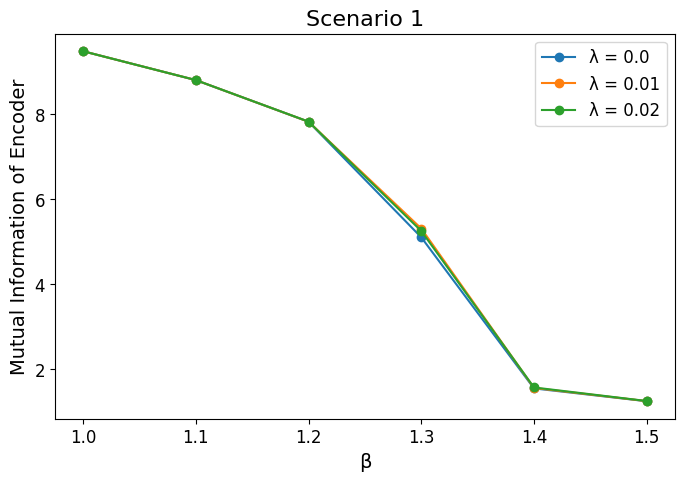

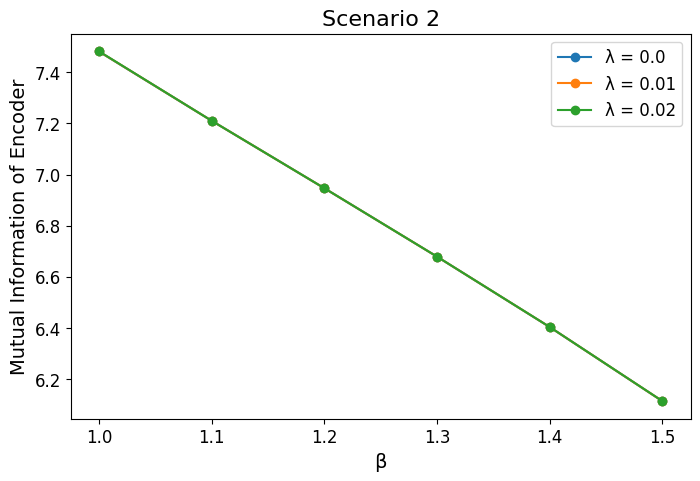

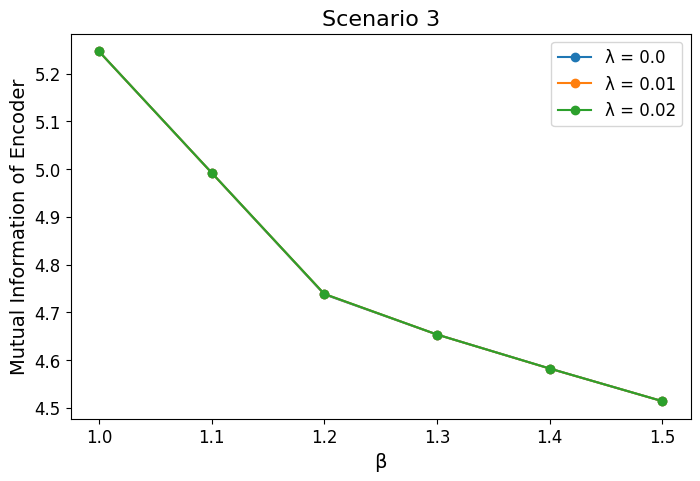

In [14]:
# Extract mutual information of encoder scores for each case
en_mi_1 = en_mi_case_1.reshape(6, 3).T
en_mi_2 = en_mi_case_2.reshape(6, 3).T
en_mi_3 = en_mi_case_3.reshape(6, 3).T

# Store mutual information of encoder in a dictionary for looping
en_mi_scores = {
    "Scenario_1": en_mi_1,
    "Scenario_2": en_mi_2,
    "Scenario_3": en_mi_3
}

# Loop through each scenario and plot
for scenario, en_mi in en_mi_scores.items():
    plt.figure(figsize=(8, 5))

    for i, lambda_val in enumerate(lambda_values):
        plt.plot(beta_values, en_mi[i], marker='o', linestyle='-', label=f'λ = {lambda_val}')

    plt.xticks(beta_values, fontsize=12)
    plt.yticks(fontsize=12)
    plt.xlabel("β", fontsize=14)
    plt.ylabel("Mutual Information of Encoder", fontsize=14)
    plt.title(f"{scenario.replace('_', ' ')}", fontsize=16)
    plt.legend(fontsize=12)

    filename = f"{scenario}_encoder_MI.png"
    save_filepath = os.path.join(SAVE_PATH, filename)
    plt.savefig(save_filepath)

    plt.show()

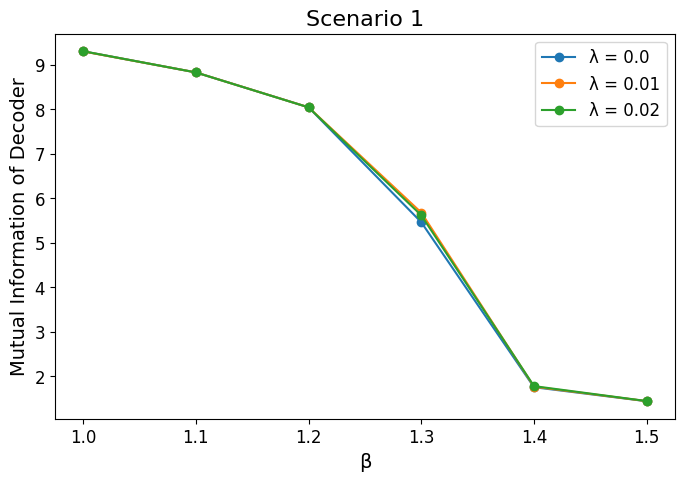

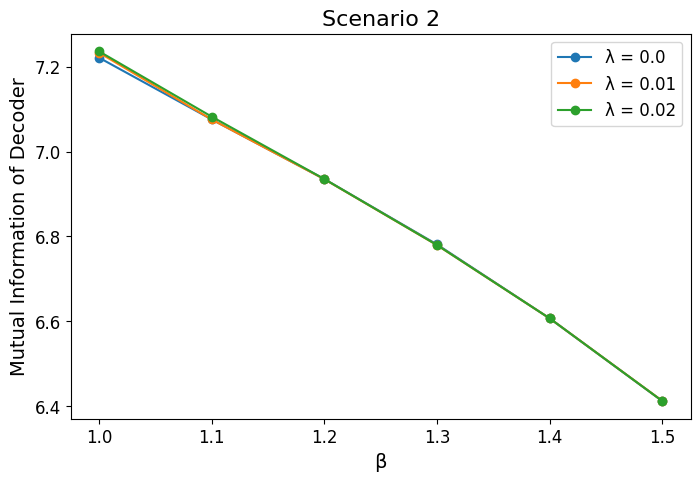

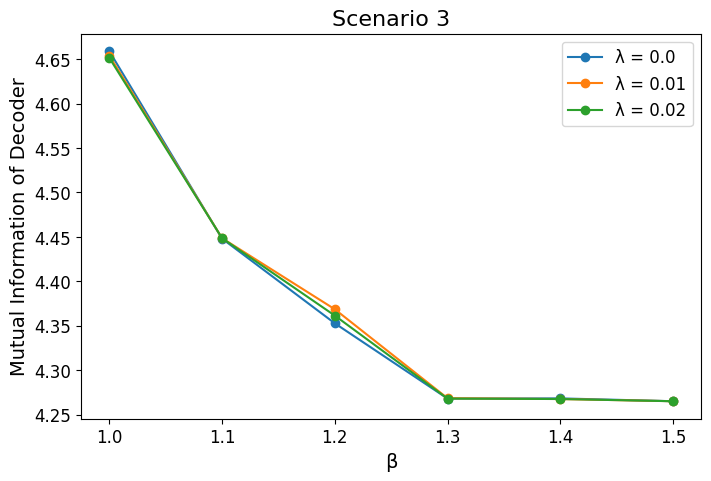

In [15]:
# Extract mutual information of decoder scores for each case
de_mi_1 = de_mi_case_1.reshape(6, 3).T
de_mi_2 = de_mi_case_2.reshape(6, 3).T
de_mi_3 = de_mi_case_3.reshape(6, 3).T

# Store mutual information of decoder in a dictionary for looping
de_mi_scores = {
    "Scenario_1": de_mi_1,
    "Scenario_2": de_mi_2,
    "Scenario_3": de_mi_3
}

# Loop through each scenario and plot
for scenario, de_mi in de_mi_scores.items():
    plt.figure(figsize=(8, 5))

    for i, lambda_val in enumerate(lambda_values):
        plt.plot(beta_values, de_mi[i], marker='o', linestyle='-', label=f'λ = {lambda_val}')

    plt.xticks(beta_values, fontsize=12)
    plt.yticks(fontsize=12)
    plt.xlabel("β", fontsize=14)
    plt.ylabel("Mutual Information of Decoder", fontsize=14)
    plt.title(f"{scenario.replace('_', ' ')}", fontsize=16)
    plt.legend(fontsize=12)

    filename = f"{scenario}_decoder_MI.png"
    save_filepath = os.path.join(SAVE_PATH, filename)
    plt.savefig(save_filepath)

    plt.show()

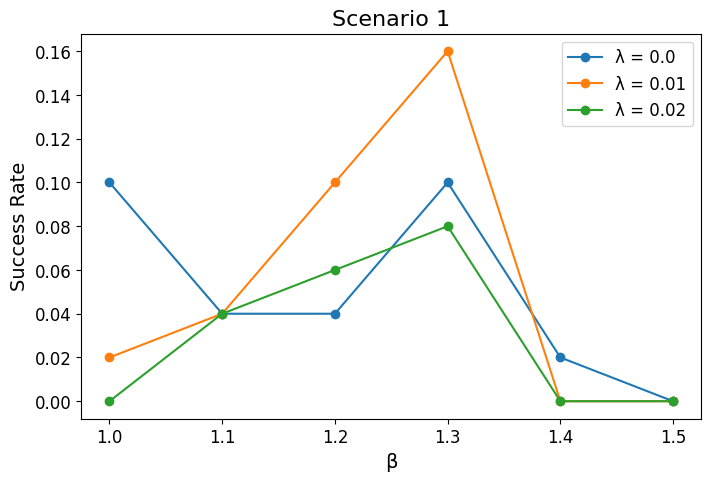

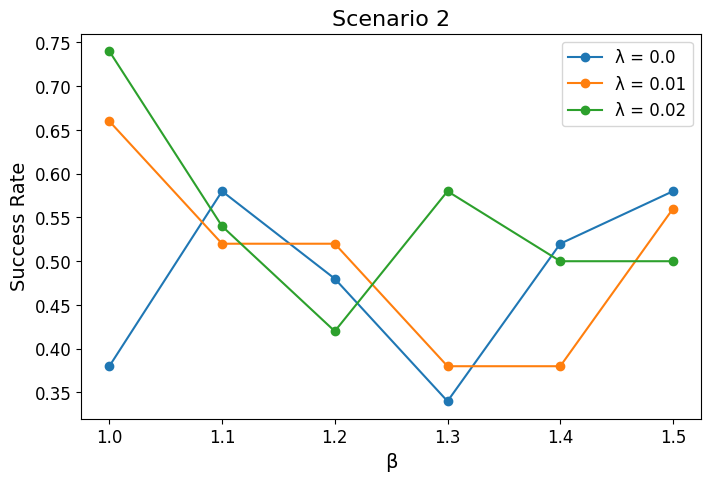

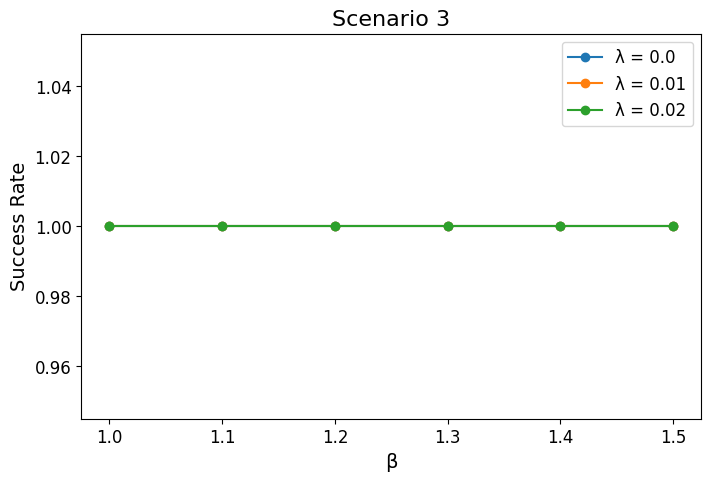

In [17]:
# Extract I3 counts for each case
I3_counts_1 = I3_count_case_1.reshape(6, 3).T
I3_counts_2 = I3_count_case_2.reshape(6, 3).T
I3_counts_3 = I3_count_case_3.reshape(6, 3).T

# Store I3 count arrays in a dictionary for looping
I3_counts = {
    "Scenario_1": I3_counts_1,
    "Scenario_2": I3_counts_2,
    "Scenario_3": I3_counts_3
}

# Loop through each scenario and plot
for scenario, I3_count in I3_counts.items():
    plt.figure(figsize=(8, 5))

    for i, lambda_val in enumerate(lambda_values):
        plt.plot(beta_values, I3_count[i], marker='o', linestyle='-', label=f'λ = {lambda_val}')

    plt.xticks(beta_values, fontsize=12)
    plt.yticks(fontsize=12)
    plt.xlabel("β", fontsize=14)
    plt.ylabel("Success Rate", fontsize=14)
    plt.title(f"{scenario.replace('_', ' ')}", fontsize=16)
    plt.legend(fontsize=12)

    filename = f"{scenario}_I3_Disentanglement.png"
    save_filepath = os.path.join(SAVE_PATH, filename)
    plt.savefig(save_filepath)

    plt.show()